# Proyecto LOST — MountainCarContinuous
### Aprendizaje por refuerzo: Q-Learning + Dyna-Q

**Integrantes:** _(completar)_  
**Materia:** Inteligencia Artificial — ORT

Este notebook es una **presentacion ejecutable** del trabajo. La logica vive en los
modulos `.py` (agentes, entrenamiento, evaluacion, graficos); aca **cargamos** los
modelos ya entrenados, evaluamos el modelo final y mostramos los graficos y
conclusiones. Cada experimento se documenta en detalle en `docs/bitacora.md`.

> Si algun modelo/resultado no estuviera presente, la funcion `ensure(...)` lo
> vuelve a entrenar automaticamente.

## 0. Dependencias y utilidades

In [1]:
import gymnasium as gym
import numpy as np
from IPython.display import Image

import train
import plotting
import experiment_configs as ec
from discretization import Discretizer
from evaluate import load_agent


def ensure(*names):
    """Garantiza que exista el modelo y los resultados de cada config;
    si falta alguno, lo entrena."""
    for name in names:
        res = train.RESULTS_DIR / f'{name}.json'
        mdl = train.MODELS_DIR / f'{name}.pkl'
        if not (res.exists() and mdl.exists()):
            print(f'[ensure] {name} no encontrado -> entrenando...')
            train.run_experiment(ec.get_config(name), save=True)
    return list(names)

print('modulos cargados OK')

modulos cargados OK


## 1. El ambiente

`MountainCarContinuous-v0`: un auto en un valle que debe llegar a la meta (arriba a
la derecha). Su motor es debil, asi que tiene que **tomar impulso** (ir para atras y
despues para adelante).

- **Observacion:** `[posicion, velocidad]` (dos numeros continuos).
- **Accion:** fuerza continua en `[-1, 1]`.
- **Recompensa:** `-0.1 * accion^2` por paso, **+100** al llegar a la meta.
  No penaliza el tiempo (clave: por eso 'no hacer nada' es un optimo local).

In [2]:
env = gym.make('MountainCarContinuous-v0')
print('Observacion:', env.observation_space)
print('  posicion en', env.observation_space.low[0], 'a', env.observation_space.high[0])
print('  velocidad en', env.observation_space.low[1], 'a', env.observation_space.high[1])
print('Accion:', env.action_space)
print('Maximo de pasos por episodio:', env.spec.max_episode_steps)
env.close()

Observacion: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  posicion en -1.2 a 0.6
  velocidad en -0.07 a 0.07
Accion: Box(-1.0, 1.0, (1,), float32)
Maximo de pasos por episodio: 999


## 2. Discretizacion

Q-Learning tabular necesita **estados discretos**, pero posicion y velocidad son
continuas. Las partimos en **casilleros** (una grilla). La tabla Q tiene forma
`(posicion x velocidad x acciones)`. Aca usamos la grilla intermedia `20x20x5`.

In [3]:
disc = Discretizer(pos_bins=20, vel_bins=20, action_bins=5)
print('Forma de la tabla Q:', disc.q_shape, '->', np.prod(disc.q_shape), 'numeros')
print('Acciones discretas (fuerza):', np.round(disc.actions, 2))

# Ejemplo: una observacion continua cae en un casillero (par de indices)
for obs in ([-0.5, 0.0], [-0.5, 0.03], [0.4, -0.01]):
    print(f'obs {obs} -> casillero {disc.state(obs)}')

Forma de la tabla Q: (20, 20, 5) -> 2000 numeros
Acciones discretas (fuerza): [-1.  -0.5  0.   0.5  1. ]
obs [-0.5, 0.0] -> casillero (7, 10)
obs [-0.5, 0.03] -> casillero (7, 14)
obs [0.4, -0.01] -> casillero (17, 8)


## 3. Q-Learning y el problema del reward disperso

**Q-Learning** llena, por prueba y error, una tabla de 'puntajes': para cada
situacion, que tan buena es cada accion. Regla de actualizacion:

$$Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma\max_{a'}Q(s',a') - Q(s,a)\,]$$

**El problema:** con la recompensa original el agente **no aprende** — como no hay
penalizacion por tiempo, converge a **'no hacer nada'** (reward 0), porque la
exploracion casi nunca alcanza la meta y el +100 nunca aparece.

**La solucion (reward shaping por energia):** le damos pistas densas de puntaje por
ganar altura y velocidad, para que aprenda a tomar impulso. Es *potential-based*, es
decir, **no cambia la politica optima**; solo guia el aprendizaje. Las metricas se
miden siempre con la **recompensa original**.

## 4. Modelo final: cargar y evaluar

Modelo elegido: **`shaped_s5`** (grilla `20x20x5`, alpha=0.1, gamma=0.99, shaping
escala 5). Lo **cargamos** desde el `.pkl` y lo evaluamos con la politica greedy
(sin exploracion) sobre el ambiente **sin shaping**.

In [4]:
ensure('shaped_s5')
agent = load_agent(str(train.MODELS_DIR / 'shaped_s5.pkl'))
print('Config del modelo:', agent.config())

env = gym.make('MountainCarContinuous-v0')
m = agent.evaluate(env, episodes=20)
env.close()

print()
print(f"Tasa de exito : {m['success_rate']*100:.0f}%")
print(f"Reward medio  : {m['mean_reward']:.2f} +/- {m['std_reward']:.2f}")
print(f"Pasos medios  : {m['mean_steps']:.0f}")

Config del modelo: {'pos_bins': 20, 'vel_bins': 20, 'action_bins': 5, 'alpha': 0.1, 'gamma': 0.99, 'epsilon_start': 1.0, 'epsilon_min': 0.01, 'epsilon_decay': 0.999, 'optimistic_init': 0.0, 'seed': 0}

Tasa de exito : 100%
Reward medio  : 93.45 +/- 0.34
Pasos medios  : 145


### Curva de aprendizaje del modelo final
Como la tasa de exito sube de 0% a 100% a medida que la tabla se llena.

guardado: C:\Users\aruet\ObligatorioIA\IA_Obligatorio-2026\MountainCarContinuous\plots\curva_shaped_s5.png


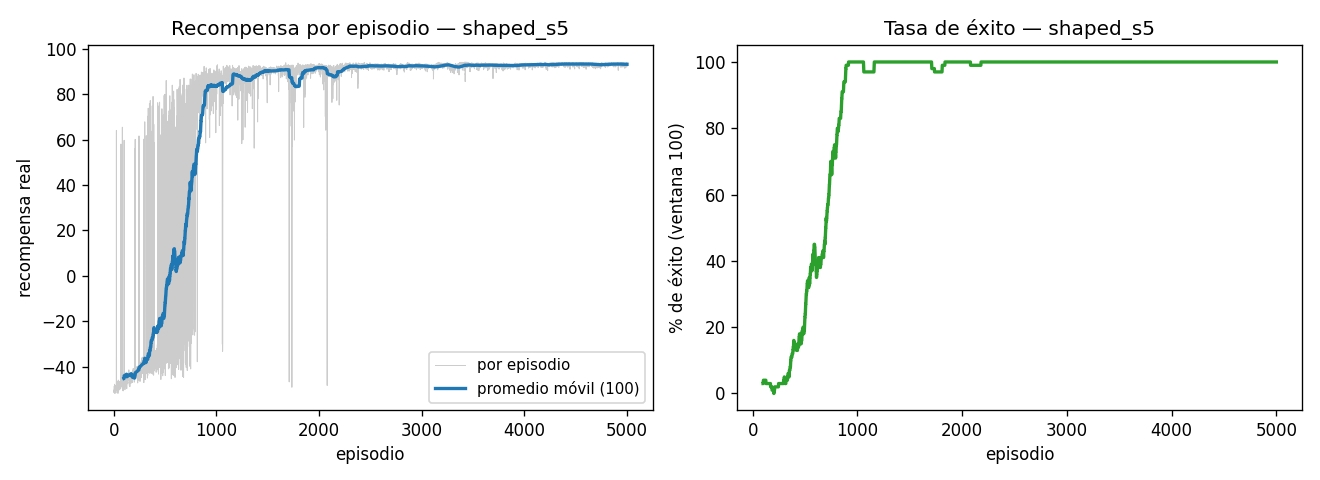

In [5]:
Image(plotting.plot_curva('shaped_s5'))

## 5. Comparacion de discretizaciones (Tarea 1)

Misma configuracion, distinta resolucion de grilla. **Las grillas chicas aprenden;
las finas fallan** con presupuesto fijo de episodios (la tabla es demasiado grande
para llenarse). Conclusion: para este problema, el 'punto justo' esta del lado grueso.

guardado: C:\Users\aruet\ObligatorioIA\IA_Obligatorio-2026\MountainCarContinuous\plots\comparacion_discretizaciones.png


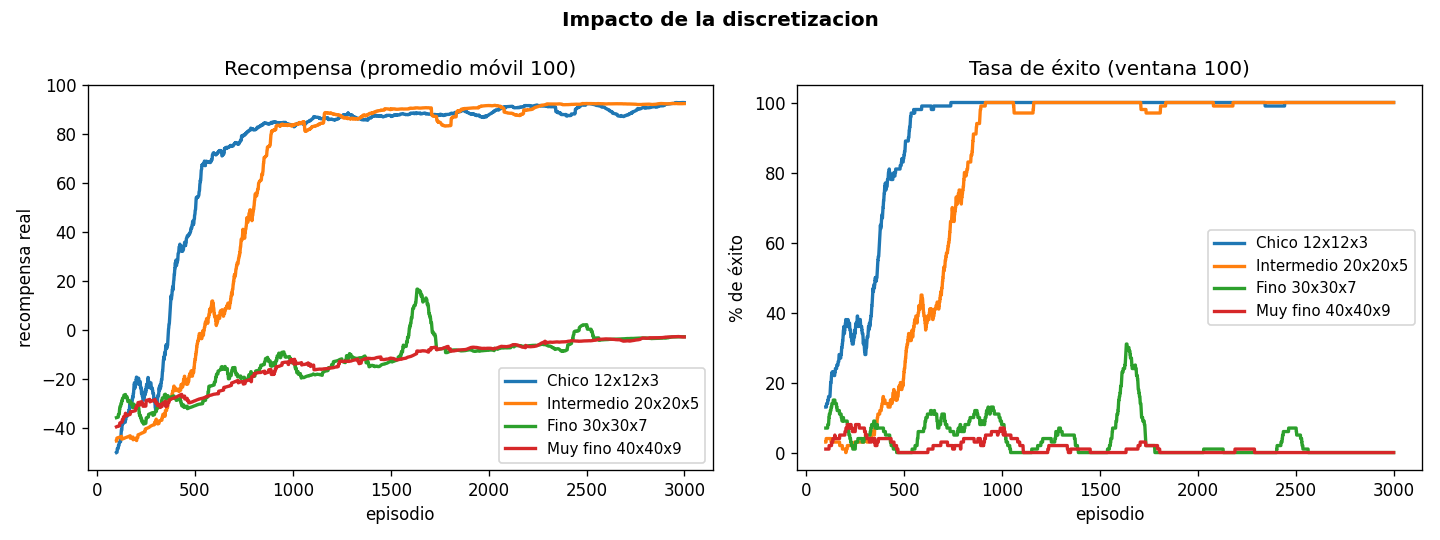

In [6]:
nombres = ensure('disc_chico', 'disc_intermedio', 'disc_fino', 'disc_muy_fino')
img = plotting.plot_comparar(
    nombres,
    out=str(plotting.PLOTS_DIR / 'comparacion_discretizaciones.png'),
    titulo='Impacto de la discretizacion',
    labels=['Chico 12x12x3', 'Intermedio 20x20x5', 'Fino 30x30x7', 'Muy fino 40x40x9'],
)
Image(img)

## 6. Q-Learning vs Dyna-Q (Tarea 4 - investigacion)

**Dyna-Q** = Q-Learning + experiencia 'imaginada' (repite transiciones ya vistas).
Con `planning_steps=0` es Q-Learning puro. Resultado: **Dyna-Q aprende en menos
episodios**, pero cuesta mas tiempo de maquina. Todas llegan al 100%; la diferencia
esta en la **velocidad de aprendizaje**, no en la calidad final.

guardado: C:\Users\aruet\ObligatorioIA\IA_Obligatorio-2026\MountainCarContinuous\plots\qlearning_vs_dynaq.png


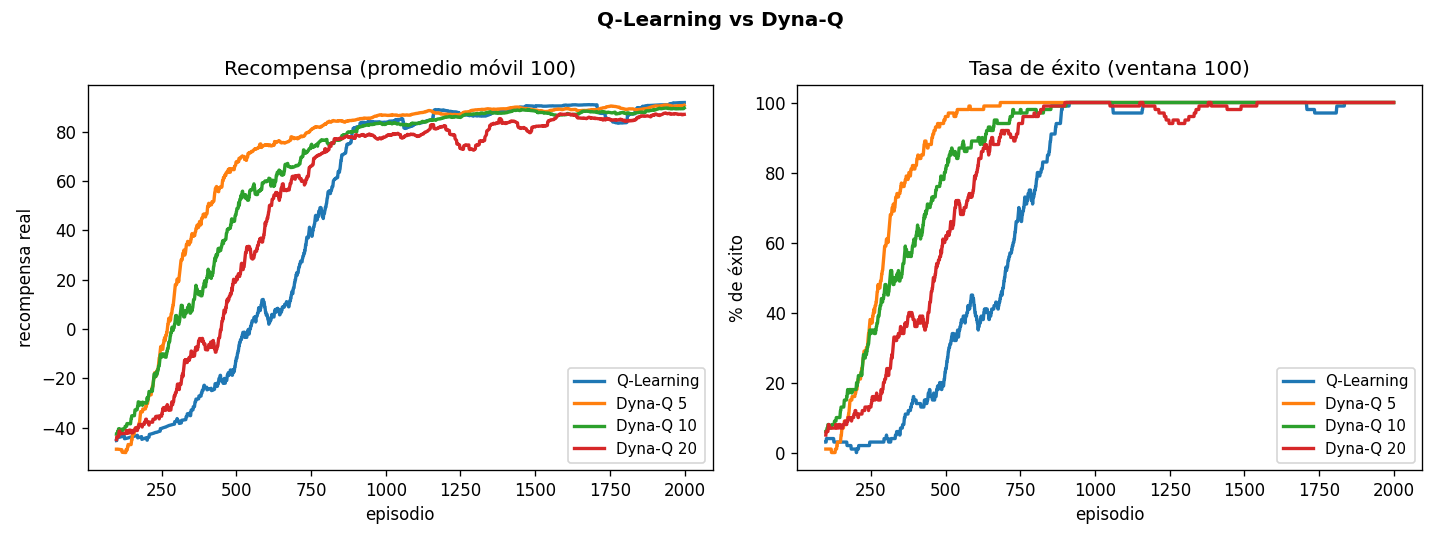

In [7]:
nombres = ensure('plan00_qlearning', 'plan05_dyna', 'plan10_dyna', 'plan20_dyna')
img = plotting.plot_comparar(
    nombres,
    out=str(plotting.PLOTS_DIR / 'qlearning_vs_dynaq.png'),
    titulo='Q-Learning vs Dyna-Q',
    labels=['Q-Learning', 'Dyna-Q 5', 'Dyna-Q 10', 'Dyna-Q 20'],
)
Image(img)

## 7. Grilla de hiperparametros (Tarea 3)

Se parte de la base (alpha=0.1, gamma=0.99, decay=0.999) y se cambia **una perilla a
la vez**. Hallazgos: **alpha** es la mas sensible (0.05 no aprende); **gamma=0.99**
da estabilidad (0.95 oscila); explorar de mas solo retrasa. Eleccion: **alpha=0.1,
gamma=0.99, decay=0.999**.

guardado: C:\Users\aruet\ObligatorioIA\IA_Obligatorio-2026\MountainCarContinuous\plots\comparacion_hiperparametros.png


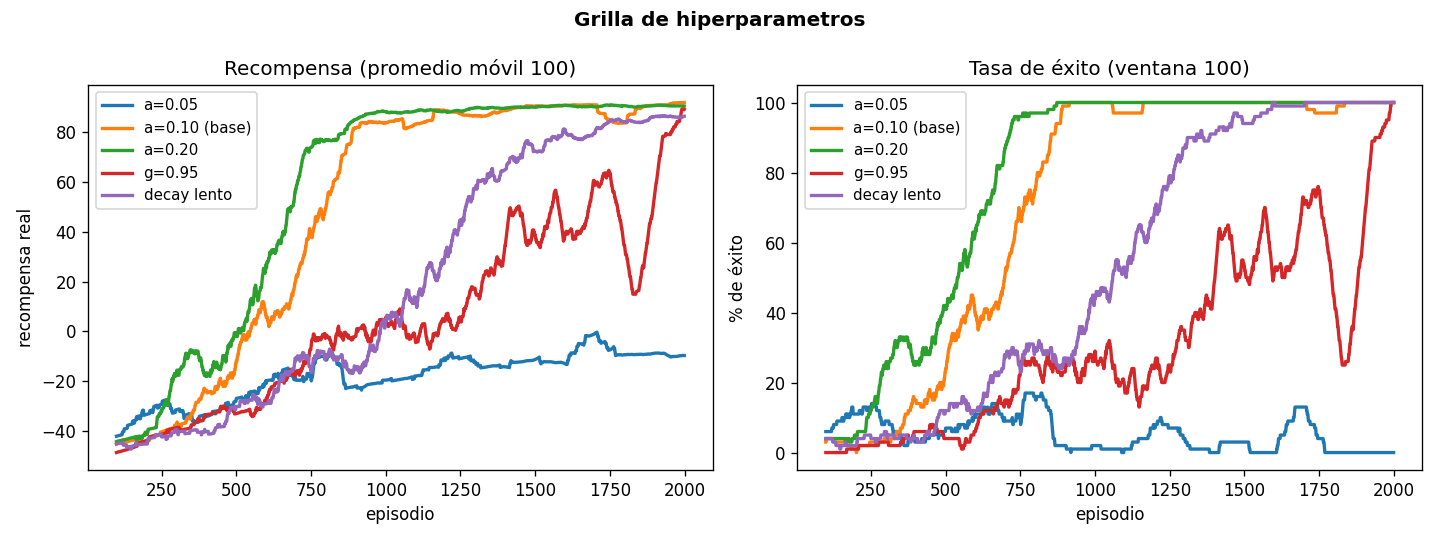

In [8]:
nombres = ensure('hp_a05_g99', 'hp_a10_g99', 'hp_a20_g99', 'hp_a10_g95', 'hp_a10_g99_slow')
img = plotting.plot_comparar(
    nombres,
    out=str(plotting.PLOTS_DIR / 'comparacion_hiperparametros.png'),
    titulo='Grilla de hiperparametros',
    labels=['a=0.05', 'a=0.10 (base)', 'a=0.20', 'g=0.95', 'decay lento'],
)
Image(img)

## 8. Conclusiones

- **Q-Learning tabular** resuelve MountainCarContinuous, pero **solo con reward
  shaping**: con la recompensa original cae en el optimo local de 'no hacer nada'.
- **Discretizacion:** grillas chicas/intermedias aprenden bien y rapido; las muy
  finas no llenan la tabla con presupuesto razonable (ver Decision 7 en la bitacora:
  ni con mas episodios ni con mas exploracion la `40x40x9` aprendio).
- **Hiperparametros:** alpha es el mas sensible; gamma alto (0.99) da estabilidad.
- **Dyna-Q** aprende en menos episodios que Q-Learning, a costa de mas computo.
- **Modelo final elegido:** `shaped_s5` (`20x20x5`) — 100% de exito y reward ~93
  (cerca del techo de 100), balance entre resolucion y velocidad de aprendizaje.

### Uso de IA generativa
Se uso IA generativa (asistente de codigo) como **apoyo** para: planificar la
estructura del codigo, implementar y depurar, disenar experimentos y redactar
documentacion. **Todos los resultados fueron ejecutados y verificados** por el grupo.